# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

In [4]:
#manually uploading my file instead of connecting to google drive
from google.colab import files
uploaded = files.upload()

Saving foodhub_order.csv to foodhub_order.csv


In [5]:
# Write your code here to read the data
df = pd.read_csv("foodhub_order.csv")

In [6]:
# Write your code here to view the first 5 rows
df.head(5)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [7]:
# Write your code here
df.shape

(1898, 9)

#### Observations: the dataset has 1898 rows and 9 columns


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [8]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations: #   
- The dataset contains 9 columns with a mix of numeric and categorical data types.
- Integer columns (int64): order_id, customer_id, food_preparation_time, delivery_time
- Float column (float64): cost_of_the_order
- Object (string) columns: restaurant_name, cuisine_type, day_of_the_week, rating



### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [9]:
# Write your code here
print(df.isna().sum())
print("-----")

#Check for unexpected unique values in object columns
for col in df.columns:
    if df[col].dtype == 'object':
        print(col)
        print(df[col].unique())
        print("-----")

#Check for unexpected unique values in numeric columns
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    print(col, df[col].unique()[:10])  # first 10 unique values
    print("-----")

#Check for negative or zero values where they shouldn’t exist
for col in ['cost_of_the_order', 'food_preparation_time', 'delivery_time']:
    print(col, (df[col] <= 0).sum())
    print("-----")

#Treating 'npt given' entry as nan
df['rating'] = df['rating'].replace("Not given", np.nan)



order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64
-----
restaurant_name
['Hangawi' 'Blue Ribbon Sushi Izakaya' 'Cafe Habana'
 'Blue Ribbon Fried Chicken' 'Dirty Bird to Go' 'Tamarind TriBeCa'
 'The Meatball Shop' 'Barbounia' 'Anjappar Chettinad' 'Bukhara Grill'
 'Big Wong Restaurant \x8c_¤¾Ñ¼' 'Empanada Mama (closed)' 'Pylos'
 "Lucky's Famous Burgers" 'Shake Shack' 'Sushi of Gari' 'RedFarm Hudson'
 'Blue Ribbon Sushi' 'Five Guys Burgers and Fries' 'Tortaria'
 'Cafe Mogador' 'Otto Enoteca Pizzeria' 'Vezzo Thin Crust Pizza'
 'Sushi of Gari 46' 'The Kati Roll Company' 'Klong' '5 Napkin Burger'
 'TAO' 'Parm' 'Sushi Samba' 'Haru Gramercy Park'
 'Chipotle Mexican Grill $1.99 Delivery' 'RedFarm Broadway' 'Cafeteria'
 'DuMont Burger' "Sarabeth's East" 'Hill Country Fried Chicken' 'Bistango'


#### Observations: I checked for missing values using df.isna().sum() and found no true NaN values. To detect hidden missing values, I inspected the unique values of every column. All numeric columns contained valid values with no placeholders. Among the object columns, only the rating column contained the string "Not given", which represents missing information. I replaced "Not given" with NaN. No other columns required missing-value treatment.



### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [10]:
# Write your code here
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


#### Observations:
- I checked the statistical summary of the dataset using df.describe(), which provides key metrics such as count, mean, standard deviation, minimum, quartiles, and maximum for all numeric columns.
- From the summary of the food_preparation_time column, the minimum, average, and maximum preparation times were extracted.
- The minimum preparation time is 20 minutes, the average preparation time is 27.37 minutes, and the maximum preparation time is 35 minutes.




### **Question 5:** How many orders are not rated? [1 mark]

In [11]:
# Write the code here
unrated_count = df['rating'].isna().sum()
unrated_count

np.int64(736)

#### Observations:
736 orders are not rated


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

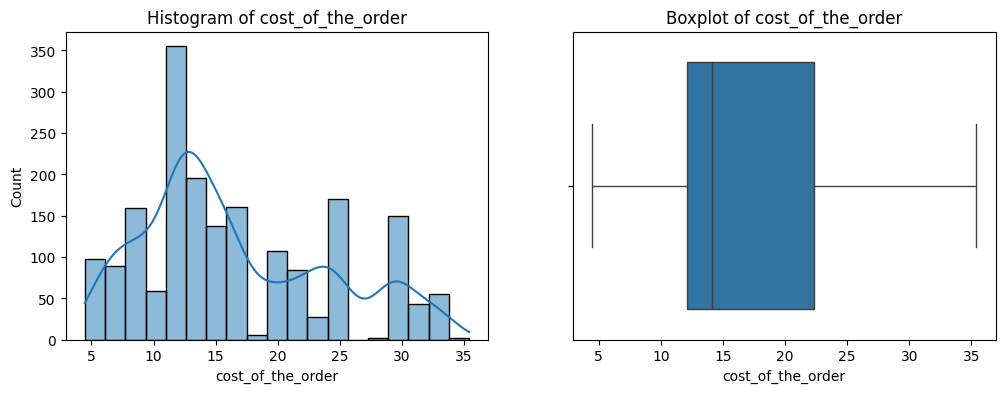

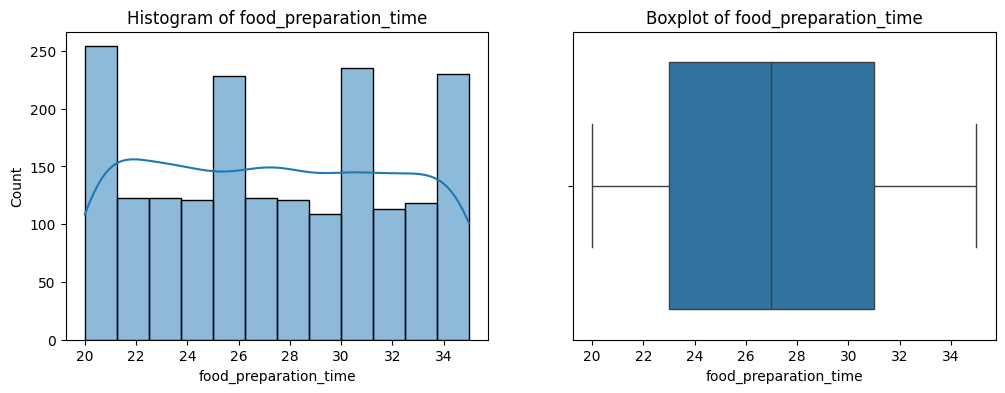

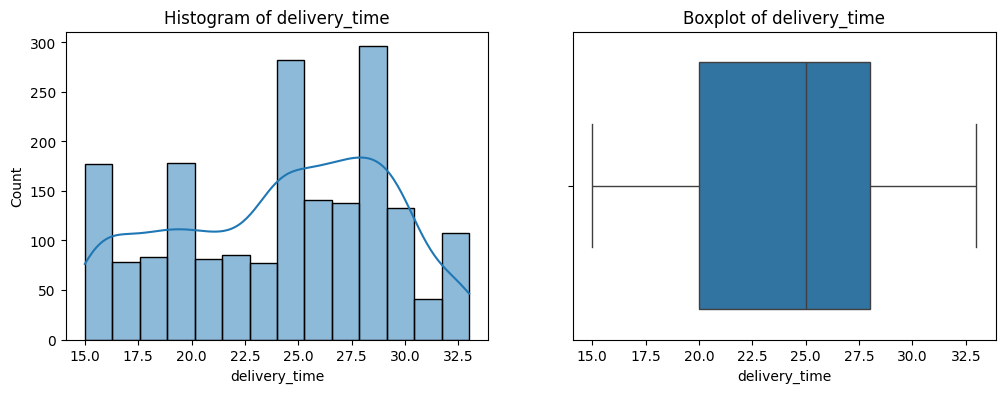

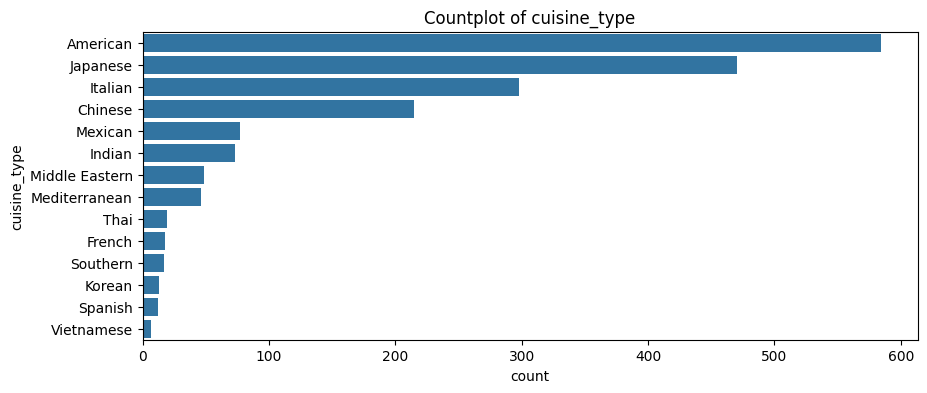

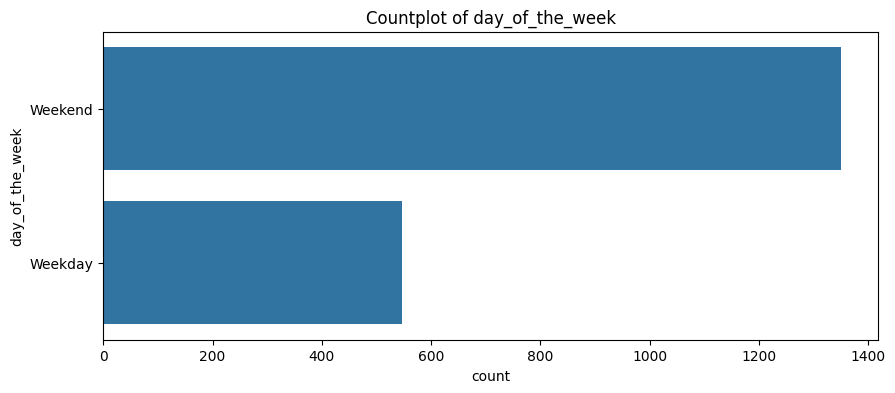

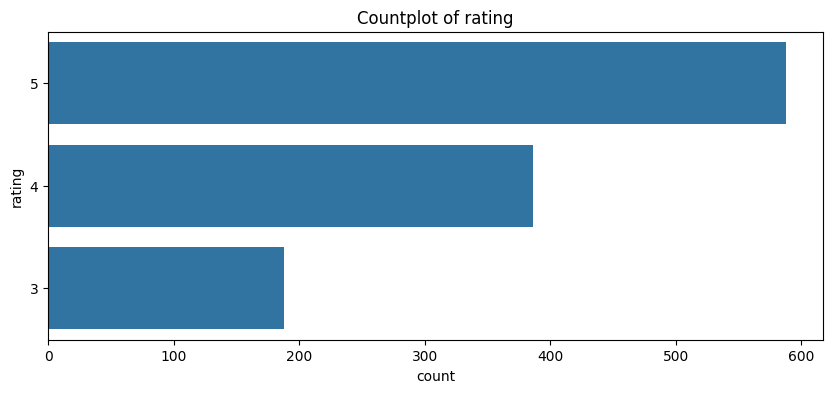

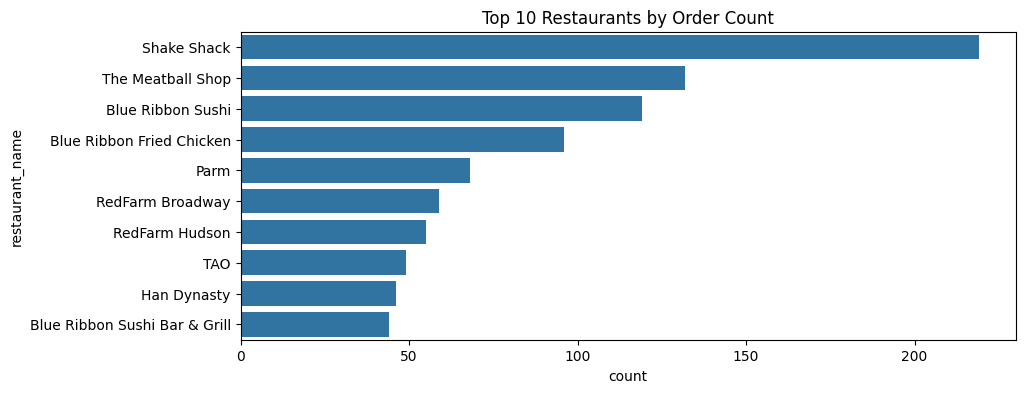

In [12]:
# Write the code here

#NUMERICAL COLUMNS
numeric_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']

for col in numeric_cols:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    plt.show()

#CATEGORICAL COLUMNS
categorical_cols = ['cuisine_type', 'day_of_the_week', 'rating']

for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.show()

plt.figure(figsize=(10,4))
sns.countplot(y=df['restaurant_name'], order=df['restaurant_name'].value_counts().head(10).index)
plt.title('Top 10 Restaurants by Order Count')
plt.show()



#### Observations:
- The restaurant_name variable has very high cardinality, meaning there are many unique restaurants. As a result, visualizations involving this variable tend to produce cluttered or overlapping labels, making patterns harder to interpret without filtering (e.g., top 10 restaurants).
- Customer ratings are generally high across the dataset, with very few low‑rating instances. This suggests overall strong customer satisfaction and consistent service quality.
- Weekend order volume is higher than weekday volume, indicating stronger customer demand and engagement during weekends.
- Food preparation time and delivery time show similar, tightly clustered ranges, reflecting stable and predictable operational performance across orders.
- A significant share of orders are priced below $25, showing that most customer purchases fall within a moderate cost range.


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

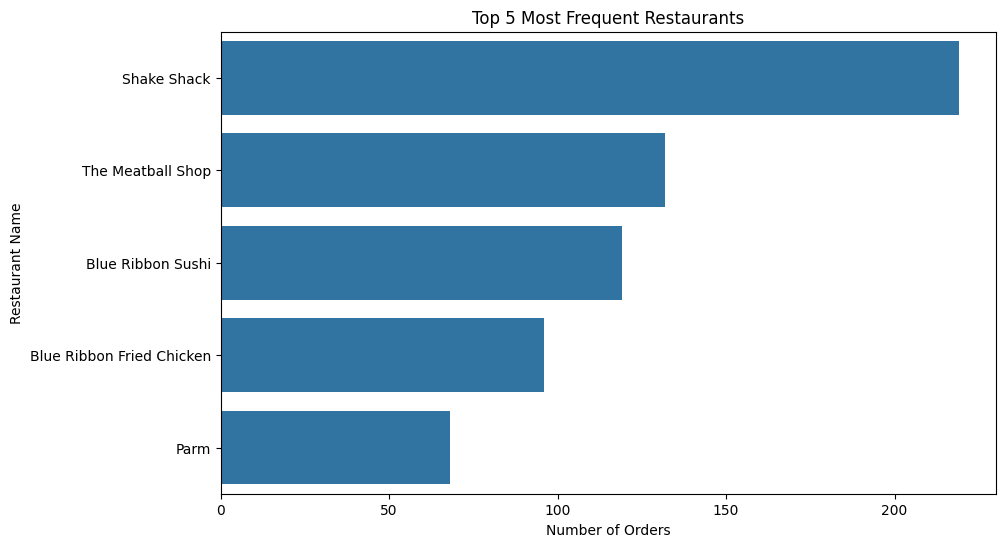

In [13]:
# Write the code here

top_restaurants = df['restaurant_name'].value_counts().head(5)

plt.figure(figsize=(10,6))
sns.barplot(x=top_restaurants.values, y=top_restaurants.index)
plt.title("Top 5 Most Frequent Restaurants")
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant Name")
plt.show()

#### Observations:
The top five restaurants in terms of number of orders were identified using value_counts(). These restaurants received the highest order volumes in the dataset, indicating they are the most frequently chosen by customers. The top five restaurants are:
- Shake shack
- The meatball shop
- Blue ribbon sushi
- Blue ribbon fried chicken
- Parm


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [14]:
# Write the code here
weekend_cuisine_counts = (
    df[df['day_of_the_week'] == 'Weekend']['cuisine_type']
    .value_counts()
)

weekend_cuisine_counts.head(1)


,count
cuisine_type,
American,415


#### Observations:
- I filtered the dataset to include only weekend orders.
- I counted the frequency of each cuisine type within weekend orders.
- The cuisine with the highest number of weekend orders is 'American', making it the most popular cuisine on weekends.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [15]:
# Write the code here
total_orders = len(df)
orders_over_20 = (df['cost_of_the_order'] > 20).sum()

percentage_over_20 = (orders_over_20 / total_orders) * 100
percentage_over_20

np.float64(29.24130663856691)

#### Observations:
- I calculated the number of orders costing more than 20 dollar by filtering the cost_of_the_order column.
- I then divided this count by the total number of orders and multiplied by 100 to obtain the percentage.
- The percentage of orders costing more than $20 is 29.2%.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [16]:
# Write the code here
df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations:
I calculated the mean delivery time using the delivery_time column. The average delivery time across all orders is 24.1 minutes, indicating the typical time customers wait for their food to arrive.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [17]:
# Write the code here
freq_cust = df['customer_id'].value_counts().head(3)
freq_cust

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
I identified the top three most frequent customers using value_counts() on the customer_id column. These customers placed the highest number of orders and therefore qualify for the 20% discount vouchers. The top three customers and their order counts are:
- Customer ID 52832 — 13 orders
- Customer ID 47440 — 10 orders
- Customer ID 83287 — 9 orders


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


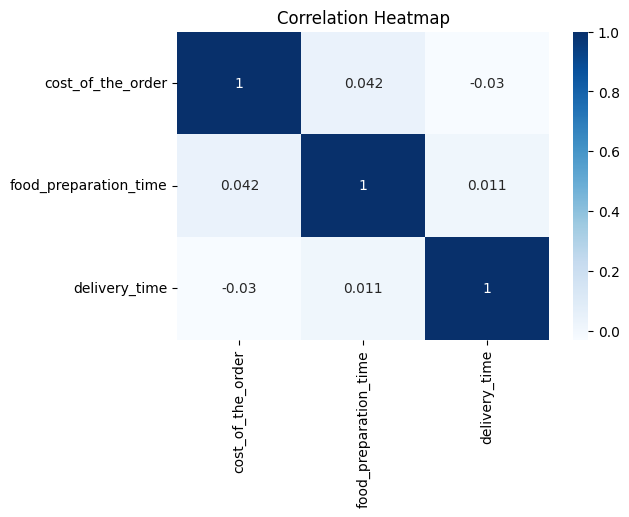

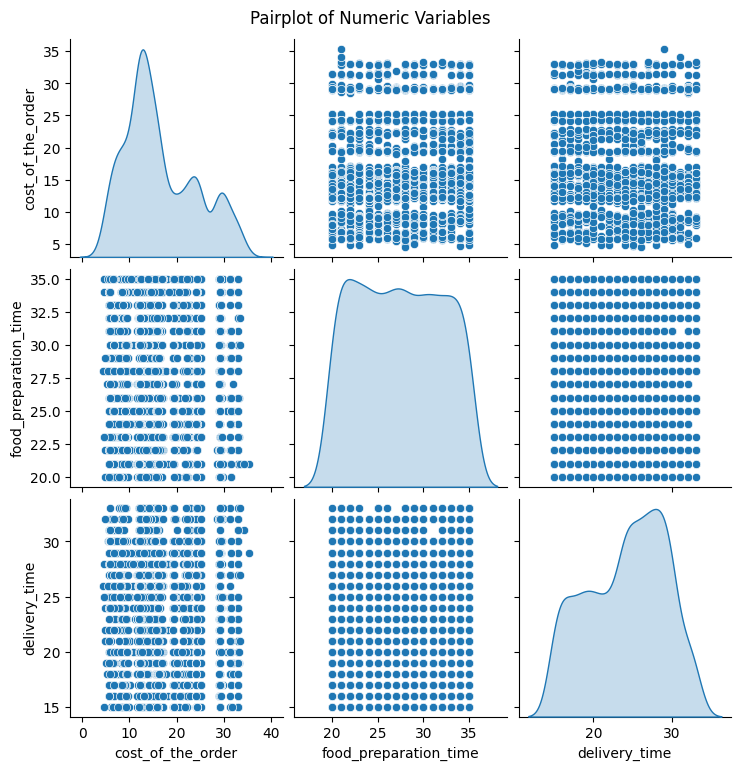

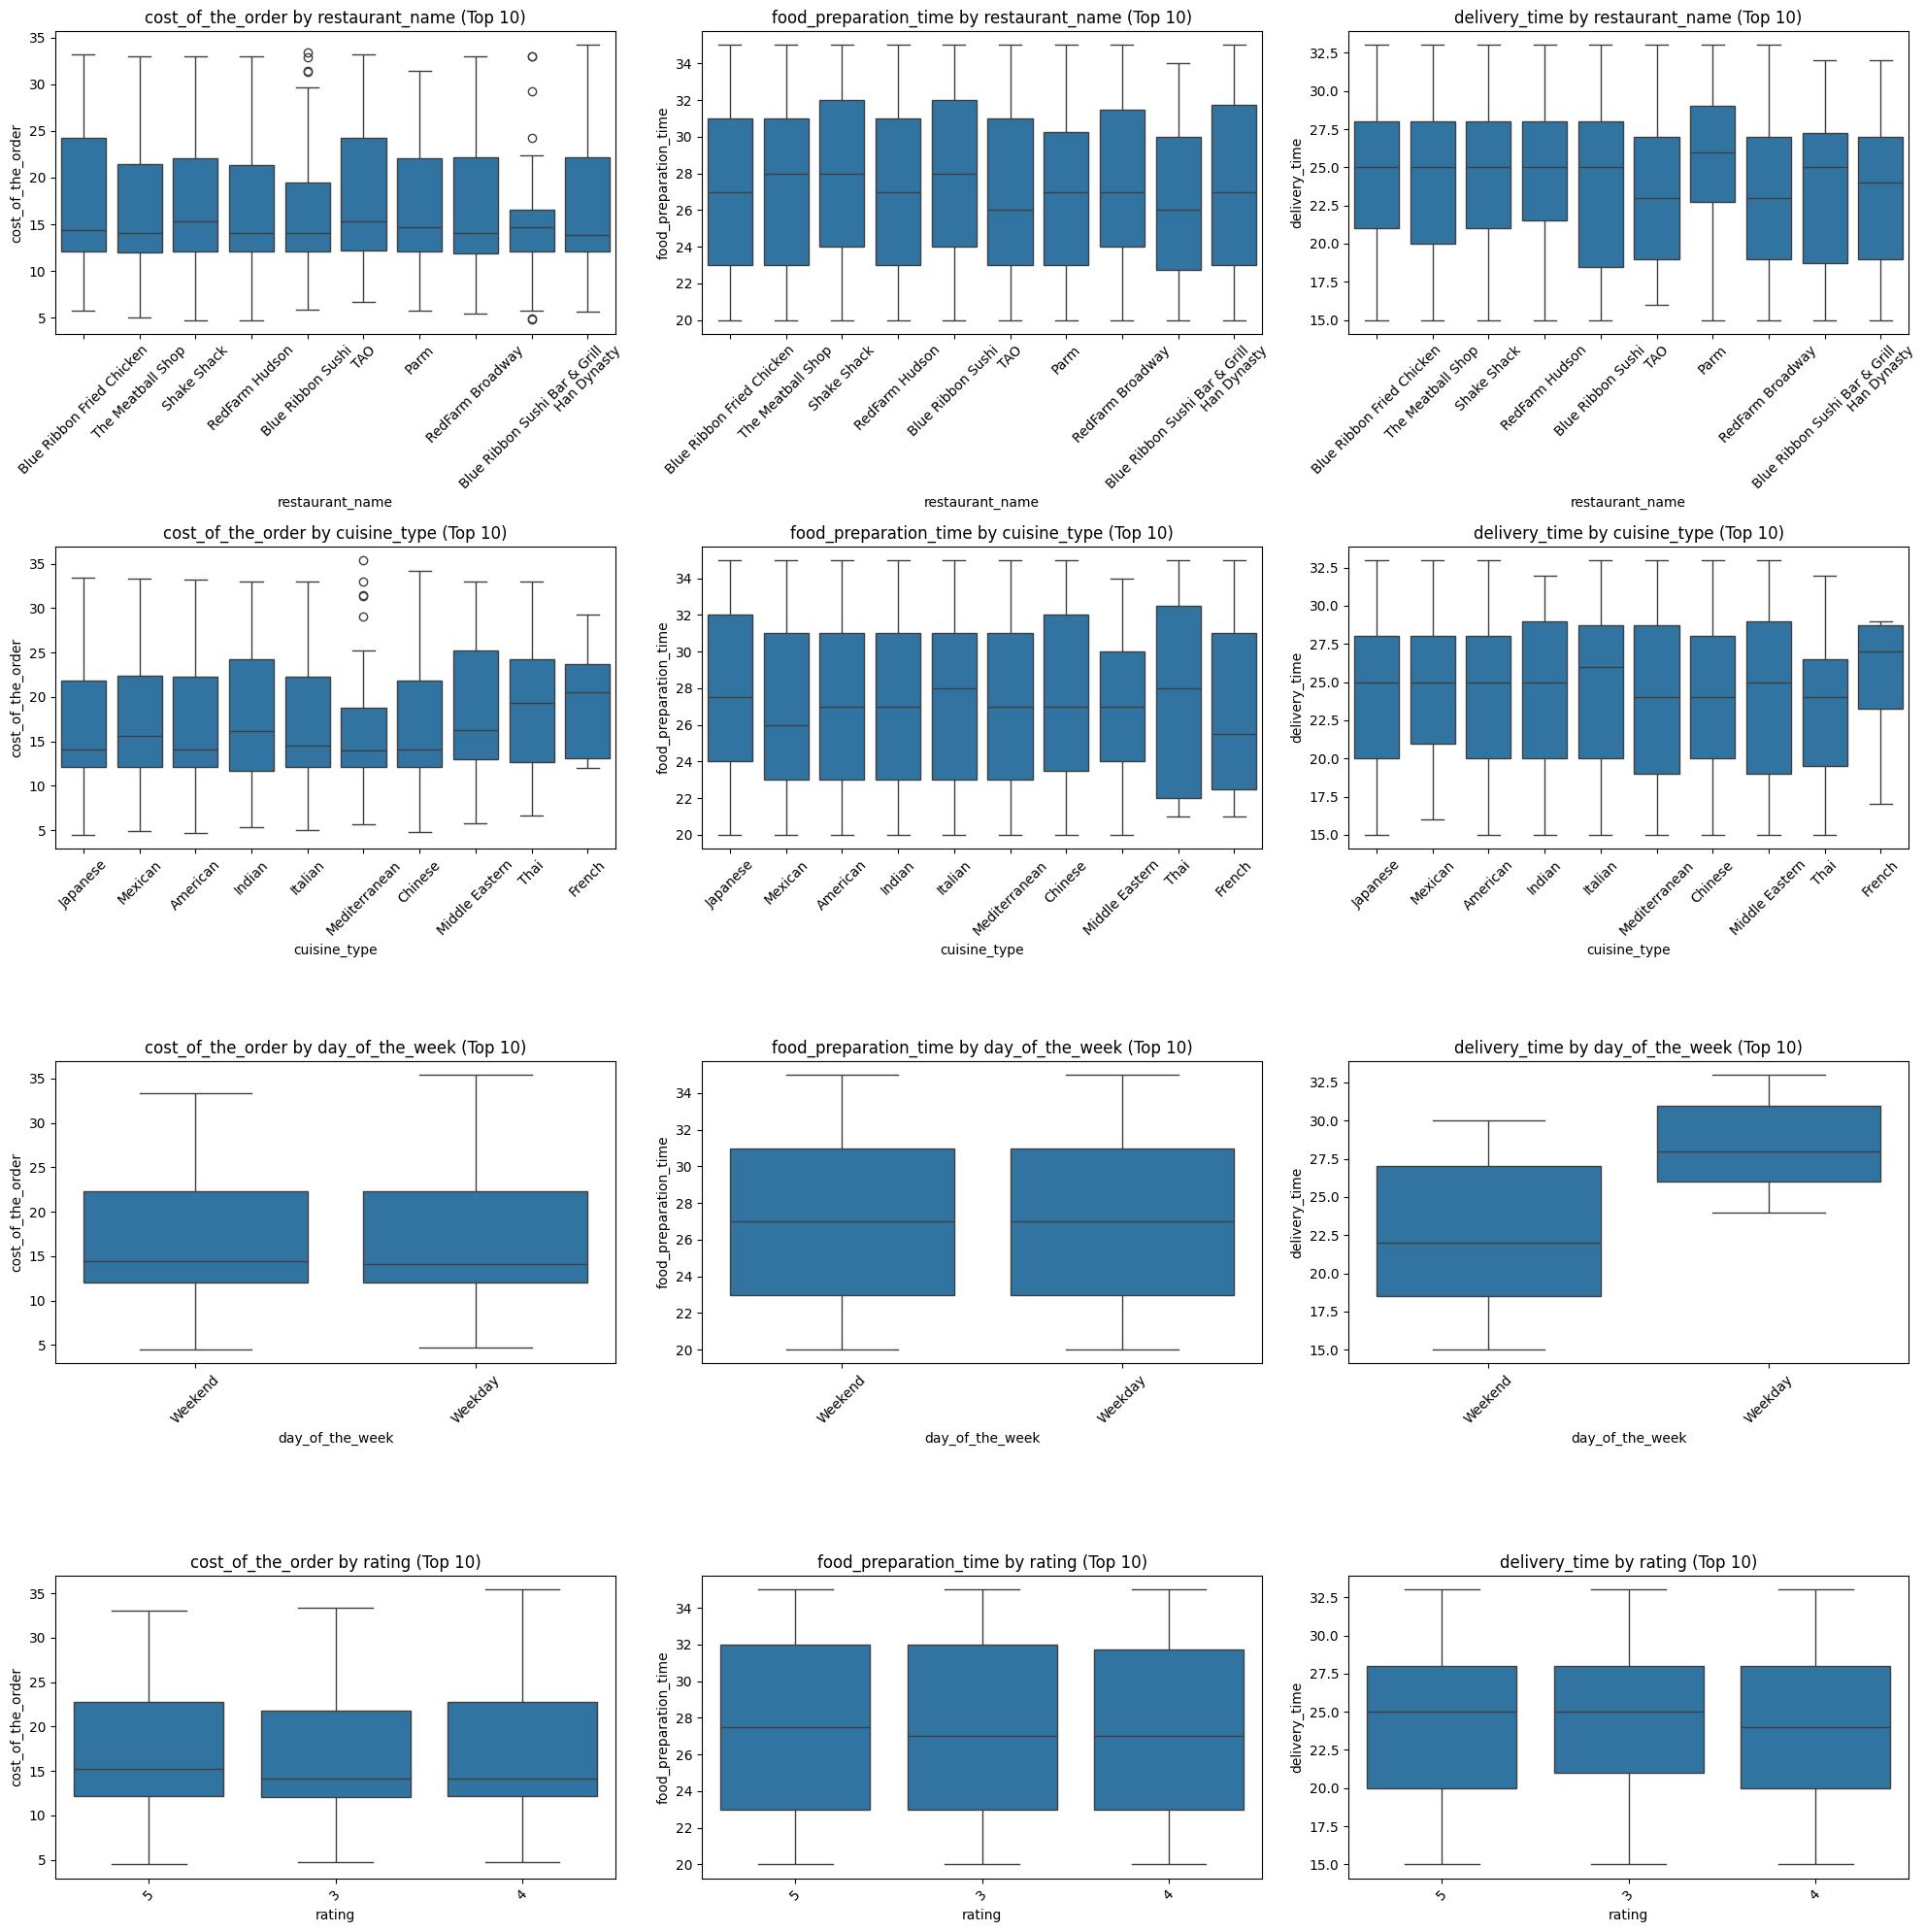

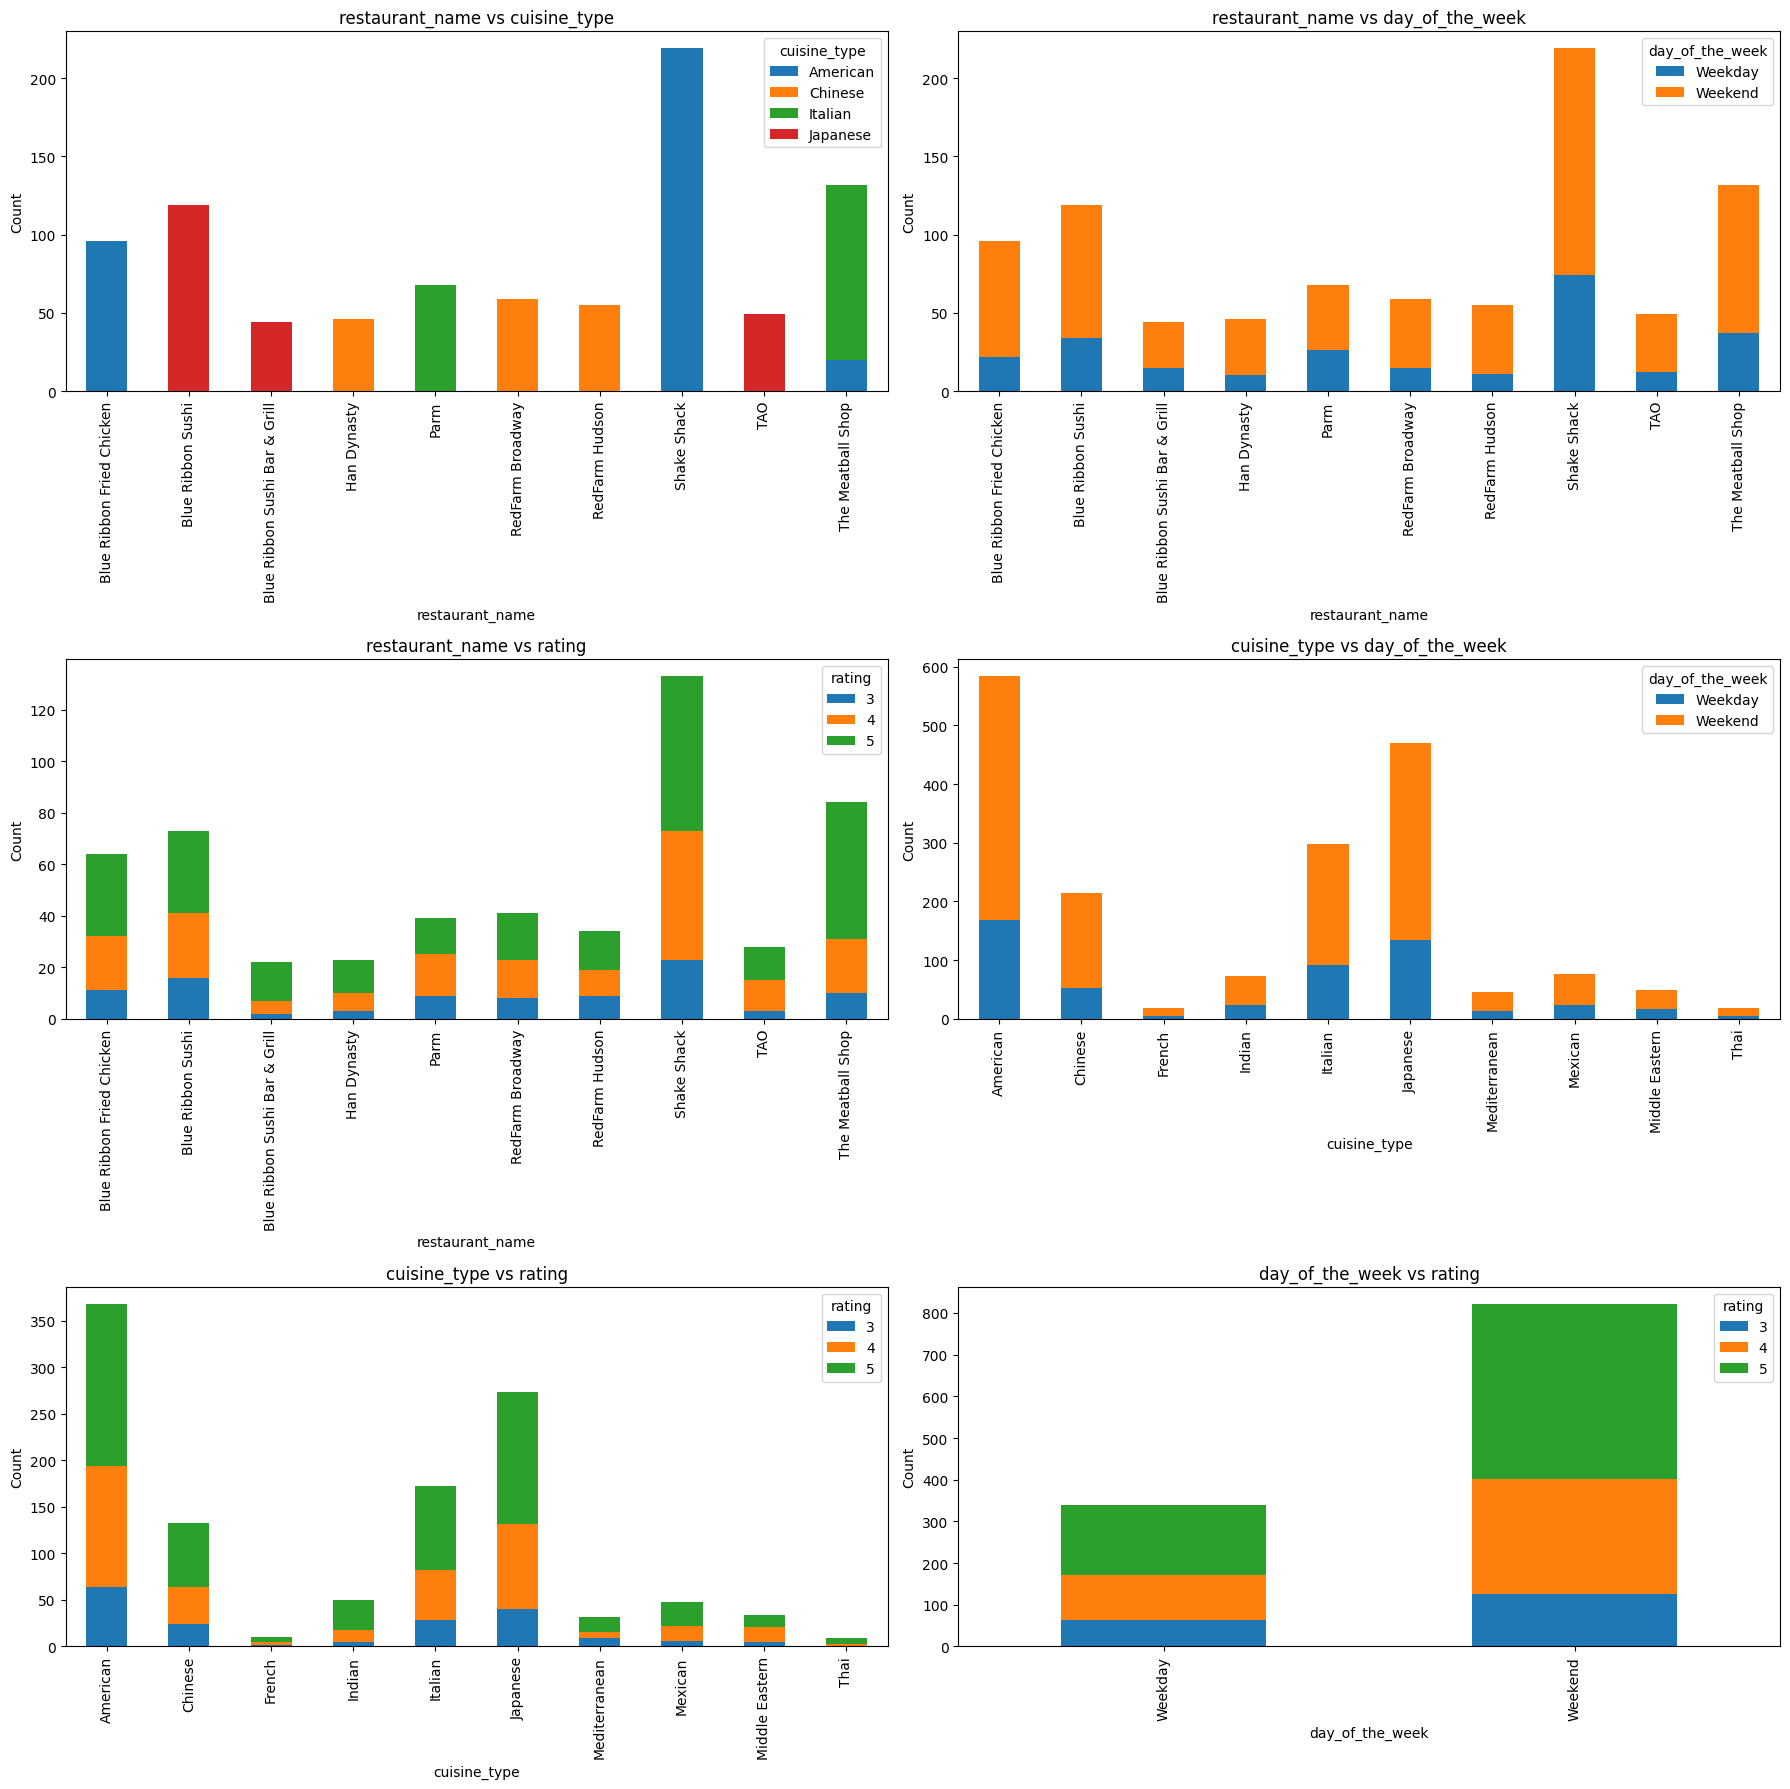

In [18]:
# Write the code here

# Correlation Heatmap (numeric vs numeric)
plt.figure(figsize=(6,4))
sns.heatmap(df[['cost_of_the_order','food_preparation_time','delivery_time']].corr(),
            annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

# Pairplot (numeric vs numeric)
sns.pairplot(df[['cost_of_the_order','food_preparation_time','delivery_time']], diag_kind='kde')
plt.suptitle("Pairplot of Numeric Variables", y=1.02)
plt.show()

# Full Spectrum Analysis (numeric vs categorical)
categorical_cols = ['restaurant_name', 'cuisine_type', 'day_of_the_week', 'rating']
numeric_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']

# Create a 4x3 grid = 12 subplots
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()

plot_index = 0

for cat in categorical_cols:
    for num in numeric_cols:

        # Limit high-cardinality categories (like restaurant_name)
        top10 = df[cat].value_counts().head(10).index
        temp = df[df[cat].isin(top10)]

        # Draw boxplot into the correct subplot
        sns.boxplot(data=temp, x=cat, y=num, ax=axes[plot_index])
        axes[plot_index].set_title(f"{num} by {cat} (Top 10)")
        axes[plot_index].tick_params(axis='x', rotation=45)

        plot_index += 1

plt.tight_layout()
plt.show()



# Full Spectrum Analysis (categorical vs categorical) (upon looking at all combinations stacked plot made the most sense)


fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

plot_index = 0

for i in range(len(categorical_cols)):
    for j in range(i+1, len(categorical_cols)):
        cat1 = categorical_cols[i]
        cat2 = categorical_cols[j]

        top10_cat1 = df[cat1].value_counts().head(10).index
        top10_cat2 = df[cat2].value_counts().head(10).index
        temp = df[df[cat1].isin(top10_cat1) & df[cat2].isin(top10_cat2)]

        ct = pd.crosstab(temp[cat1], temp[cat2])

        ct.plot(kind='bar', stacked=True, ax=axes[plot_index])
        axes[plot_index].set_title(f"{cat1} vs {cat2}")
        axes[plot_index].set_xlabel(cat1)
        axes[plot_index].set_ylabel("Count")

        plot_index += 1

plt.tight_layout()
plt.show()



#### Observations:
The multivariate analysis explored relationships across numeric variables, numeric–categorical combinations, and categorical–categorical interactions. The correlation heatmap and pairplot show that the numeric variables (cost_of_the_order, food_preparation_time, and delivery_time) have weak correlations, with only a mild positive relationship between preparation time and delivery time. This indicates that while longer preparation may slightly extend delivery time, overall operational timing is consistent and tightly clustered across orders.
The numeric–categorical boxplots reveal that order cost varies the most across categories, particularly by cuisine type, where some cuisines consistently show higher median costs. In contrast, preparation and delivery times remain relatively stable across most categorical groups, reflecting standardized processes. Delivery time shows small but meaningful increases on weekends, and lower customer ratings tend to align with slightly longer delivery times, suggesting a service‑quality effect.
The categorical–categorical stacked bar charts highlight distribution patterns between category pairs. Cuisine types show different ordering patterns across days of the week, and ratings are generally high across most categories, with no extreme deviations. Restaurant‑level comparisons (limited to the top 10) show variation in volume but similar rating distributions, indicating consistent customer satisfaction across high‑frequency restaurants.
Overall, the multivariate analysis shows that numeric variables are operationally stable, while categorical factors especially cuisine type and day of the week explain most of the meaningful variation in cost and delivery patterns.


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [19]:
# Write the code here

#converting rating column to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Group by restaurant and calculate rating count + average rating
rating_stats = df.groupby('restaurant_name').agg(
    rating_count = ('rating', 'count'),
    avg_rating = ('rating', 'mean')
).reset_index()

qualified_restaurants = rating_stats[
    (rating_stats['rating_count'] > 50) &
    (rating_stats['avg_rating'] > 4)
]

qualified_restaurants

,restaurant_name,rating_count,avg_rating
20,Blue Ribbon Fried Chicken,64,4.328125
21,Blue Ribbon Sushi,73,4.219178
136,Shake Shack,133,4.278195
153,The Meatball Shop,84,4.511905


#### Observations:
The results show that only four restaurants meet the promotional criteria of having more than 50 ratings and an average rating above 4. These restaurants are Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, and The Meatball Shop.
This makes them strong candidates for the company’s promotional offer, as they combine both popularity and high performance in customer satisfaction.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [20]:
# Write the code here

# Create commission column based on cost rules
df['commission'] = df['cost_of_the_order'].apply(
    lambda x: 0.25*x if x > 20 else (0.15*x if x > 5 else 0)
)

# Total revenue
net_revenue = df['commission'].sum()
net_revenue

np.float64(6166.303)

#### Observations:
The company’s net revenue was calculated by applying a 25% commission to all orders costing more than 20 dollars and a 15% commission to orders costing more than $5. A commission column was created using conditional logic, and the total revenue was obtained by summing the commission across all orders. The resulting 6166.3 dollars represents the total earnings generated by the company from all restaurant orders.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [21]:
# Write the code here

df['total_time'] = df['food_preparation_time'] + df['delivery_time']

percentage_over_60 = (df['total_time'] > 60).mean() * 100
percentage_over_60

np.float64(10.537407797681771)

#### Observations:
About 10.5% of all orders take more than 60 minutes from placement to delivery, and this figure reflects how preparation and delivery times combine to shape the customer experience. Total time was calculated by adding food preparation time and delivery time for each order, and the percentage was computed by checking how many of these totals exceeded 60 minutes.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [22]:
# Write the code here
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
The comparison shows that weekend orders are delivered noticeably faster than weekday orders. On weekdays, the average delivery time is about 28.3 minutes, while on weekends it drops to around 22.5 minutes, a difference of nearly six minutes. This suggests that weekday operations experience more congestion, likely due to higher traffic, work‑hour constraints, or more simultaneous orders during lunch and evening peaks. Weekends, by contrast, may offer smoother delivery conditions, with couriers facing less traffic and restaurants operating with more flexible preparation schedules. The result indicates that the company’s delivery system performs more efficiently on weekends, and weekday delays may be an area for operational improvement.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
The dataset shows a business that is generally performing well operationally, with stable preparation and delivery times, strong customer satisfaction, and clear patterns in cuisine‑level and restaurant‑level performance. Numeric variables such as preparation time and delivery time show weak correlations, indicating that delays in one stage do not strongly propagate to the other. Most orders fall within a predictable time window, and only about 10.5% exceed 60 minutes from order to delivery, suggesting that long delays are the exception rather than the norm.
Customer ratings are consistently high across restaurants and cuisines, with only small variations. Restaurants with higher order volumes tend to maintain strong average ratings, indicating that popularity does not compromise service quality. Cuisine type emerges as one of the most influential categorical variables: it affects order cost, rating patterns, and ordering frequency across weekdays and weekends. Day‑type also plays a role, with weekend orders being delivered faster on average than weekday orders, likely due to reduced traffic or more flexible operational capacity.

Insights from categorical relationships
- Cuisine type is a major driver of customer behavior. Certain cuisines attract more orders and command higher average costs, making them strong revenue contributors.
- Ratings are consistently high, but some cuisines and restaurants show slightly higher proportions of 5‑star ratings, indicating opportunities to highlight these categories in marketing.
- Weekday vs weekend patterns show that demand and delivery efficiency vary, with weekends offering faster delivery times and more balanced order distribution across cuisines.
- Restaurant‑level variation exists in order volume but not in satisfaction, suggesting that top restaurants are both popular and reliable.




### Recommendations:

- Promote high‑performing cuisines and restaurants. Cuisines with higher average costs and strong ratings (e.g., Japanese, Italian, or specific top‑rated restaurants like Shake Shack and The Meatball Shop) should be featured prominently in marketing campaigns, as they drive both revenue and customer satisfaction.
- Use customer ratings strategically. Since ratings are consistently high, highlight “Top Rated” or “Most Loved” restaurants in the app to reinforce trust and encourage repeat orders. Restaurants with >50 ratings and >4 average rating are ideal candidates for promotional partnerships.
- Optimize weekday delivery operations. Weekday delivery times are noticeably slower than weekend times. Improving courier allocation or restaurant staffing during weekday peaks could reduce delays and further improve customer satisfaction.
- Target cuisines with growth potential. Cuisines that show moderate order volume but strong ratings could benefit from targeted promotions or discounts to increase visibility and demand.
- Address long‑tail delays. Although only 10.5% of orders exceed 60 minutes, these delays can disproportionately affect customer perception. Identifying the restaurants or time windows associated with these longer waits can help reduce outliers.
- Leverage weekend efficiency. Since weekends show faster delivery, the company can run weekend‑specific campaigns (e.g., “Fast Delivery Weekend Deals”) to capitalize on operational strengths.


---